# **Project Introduction:**

**Project Name:** Analysis Entertainment in KSA.



This project is part of AI Programming course (AI221), focuses on cleaning, analyzing, and visualizing a real world dataset using Python. The selected dataset contains information about entertainment places in the Kingdom of Saudi Arabia.

Analyzing entertainment data is useful for the country because it helps support
the ongoing development of the entertainment sector, which is an important part of Saudi Vision 2030.
 The results of this analysis can help decision-makers understand public opinions, improve the quality of services, and enhance visitor experiences in different regions of Saudi Arabia.




**Name of Datase:** Entertainment in Saudi Arabia

**Dataset type:** CSV

**Source:** Kaggle

**Number of rows:** 564

**Number of rows substituted:** 500

**Main columns:**
-Name
-Rating
-Review count
-Genre
-Location
-Best comments


*Link of Dataset in Kaggle:*
https://www.kaggle.com/datasets/anas123siddiqui/entertainment-in-saudi-arabia


**Group (5) members:**

*   وتين الفريدي (Leader)
*   فاطمة القحطاني
*   شهد الرحيلي
*   شهد الودعاني
*   بيان مدخلي


#Importing needed libraries:

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Loading dataset:

In [62]:
from google.colab import files
uploaded = files.upload()

Saving Entertainment_KSA.csv to Entertainment_KSA (4).csv


In [63]:
df = pd.read_csv("Entertainment_KSA.csv")

#Dataset Information:

In [64]:
print("First 5 rows of DataSet:\n")
df.head()

First 5 rows of DataSet:



,Unnamed: 0,name,rating,review_count,genre,location,best_comment
0,0,المسرح الروماني | Roman Theater,4.1,-151,Performing arts theater,Al Uqayr Saudi Arabia,NaN
1,1,Maraya,4.6,(1.1T),Concert hall,Al Atheeb Saudi Arabia,"""Also the theater is another level of perfecti..."
2,2,"Novo Cinemas, Seef Mall",4.3,-801,Movie theater,"Muharraq, Bahrain · In Seef Mall - Arad, Muharraq","""The theater was comfortable and the screening..."
3,3,Education Department Theater,4,-169,Performing arts theater,NaN,"""Screen size is good enough."""
4,4,Muvi Cinemas - Jubail Mall,4.3,-871,Movie theater,Al Jubail Saudi Arabia · In Cenomi Al Jubail Mall,NaN


In [65]:
print(f"number of columns  and rows: {df.shape} \n")

df.info()

number of columns  and rows: (564, 7) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    564 non-null    int64 
 1   name          559 non-null    object
 2   rating        564 non-null    object
 3   review_count  562 non-null    object
 4   genre         541 non-null    object
 5   location      539 non-null    object
 6   best_comment  342 non-null    object
dtypes: int64(1), object(6)
memory usage: 31.0+ KB


#Stage1: Processing the dataset.

In [66]:
#taking sub of dataset
df = df.sample(n=500, random_state=42)
df.shape

(500, 7)

In [67]:
# checking(NaN values).
print (f"missing_values count: ")
missing_values = df.isnull().sum()
missing_values

missing_values count: 


,0
Unnamed: 0,0
name,5
rating,0
review_count,2
genre,20
location,23
best_comment,196


In [68]:
# Removing rows with NaN in these columns
df.dropna(subset=['name','genre', 'location'], inplace=True)

# Filling missing values
df['best_comment'] = df['best_comment'].fillna(" ")
df['review_count'] = df['review_count'].fillna(0)

# Fill missing Names
df['name'] = df['name'].fillna('Unknown')


In [69]:
# Rechecking(NaN values).
print (f"missing_values count: ")
missing_values = df.isnull().sum()
missing_values

missing_values count: 


,0
Unnamed: 0,0
name,0
rating,0
review_count,0
genre,0
location,0
best_comment,0


In [70]:
#1.Remove an unneeded column
df= df.drop(columns=['Unnamed: 0'])
print(df.columns)


Index(['name', 'rating', 'review_count', 'genre', 'location', 'best_comment'], dtype='object')


In [71]:
#Removing duplicate records.

print(f"duplicate records: {df.duplicated().sum()}")
df.describe()

print(f"dublicate count before removing: {df.duplicated().sum()}")

df = df.drop_duplicates(subset=['name', 'genre', 'location'])

print(f"dublicate count after removing: {df.duplicated().sum()}")
df

duplicate records: 188
dublicate count before removing: 188
dublicate count after removing: 0


,name,rating,review_count,genre,location,best_comment
537,Syrup,4.5,-406,Corporate office,Ad Dilam Saudi Arabia,
522,Triangle Park,3.9,-109,Garden,Riyadh Saudi Arabia,
234,DAZ داز,4.5,-278,Amusement center,Jeddah Saudi Arabia,"""My daughter’s favorite place !"""
523,Chuck E Cheese's,4.1,(2.4T),₹₹,Riyadh Saudi Arabia,"""Best kid's and family entertainment place"""
485,تشكي تشيز,4,(2.4T),₹,Riyadh Saudi Arabia,
...,...,...,...,...,...,...
156,Far-is studio,4.6,-17,Museum,Riyadh Saudi Arabia,
350,Snowy Forest,3.6,-417,Amusement center,Riyadh Saudi Arabia,
445,Lambee Tily,4.2,(1.2T),Amusement center,Riyadh Saudi Arabia,"""NYC place... Kidz njying.... Tq waad for help..."
201,The old palace,3.9,-69,Tourist attraction,Al Moqbel Palaces Saudi Arabia,Closed ⋅ Opens 6:30 am Wed


In [72]:
 #Clean text data:
df.loc[:, 'best_comment'] = (
    df['best_comment']
    .astype(str)                                      #Convert all values to string
    .apply(lambda x: re.sub(r'[^\w\s]', '', x))       #Remove punctuation and emojis
    .apply(lambda x: x.lower())                        #Convert text to lowercase
    .apply(lambda x: x.strip())

)

print("after clean  Best_comment column:\n")
df[['best_comment']].head()



after clean  Best_comment column:



,best_comment
537,
522,
234,my daughters favorite place
523,best kids and family entertainment place
485,


In [73]:
 #Tokenizing text data:
df['best_comment'] = (
    df['best_comment']
    .apply(lambda x: x.split())      #Split text into tokens
)


print("after tokens  Best_comment column:\n")
df[['best_comment']].head()

after tokens  Best_comment column:



,best_comment
537,[]
522,[]
234,"[my, daughters, favorite, place]"
523,"[best, kids, and, family, entertainment, place]"
485,[]


In [74]:
# Reformatting data:

# 1. Renaming columns
df = df.rename(columns={
    'name': 'Name',
    'rating': 'Rating',
    'review_count': 'Review_count',
    'genre': 'Genre',
    'location': 'Location',
    'best_comment': 'Best_comment'
})


# 1. Reformatting Review_count
def clean_review_count(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if any(c.isalpha() for c in val) and 'T' not in val:
        return np.nan
    try:
        val = val.replace('(', '').replace(')', '')
        if 'T' in val:
            return float(val.replace('T','')) * 1e12
        else:
            return float(val)
    except:
        return np.nan


df['Review_count'] = df['Review_count'].apply(clean_review_count)

df = df.dropna(subset=['Review_count'])

#Convert rating and review_count to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Review_count'] = pd.to_numeric(df['Review_count'], errors='coerce')

print("Checking values are updated:\n")
df.info()


Checking values are updated:

<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 537 to 190
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          273 non-null    object 
 1   Rating        273 non-null    float64
 2   Review_count  273 non-null    float64
 3   Genre         273 non-null    object 
 4   Location      273 non-null    object 
 5   Best_comment  273 non-null    object 
dtypes: float64(2), object(4)
memory usage: 14.9+ KB


In [75]:
#Normalizing or scaling data:

#Normalizing rating column
min_rating = df['Rating'].min()
max_rating = df['Rating'].max()

df['Rating_scaled'] = (df['Rating'] - min_rating) / (max_rating - min_rating)

#Normalizing review_count column
min_review = df['Review_count'].min()
max_review = df['Review_count'].max()
df['Review_count_scaled'] = (df['Review_count'] - min_review) / (max_review - min_review)

#Show results after scaling
df[['Rating', 'Rating_scaled', 'Review_count', 'Review_count_scaled']].head()


,Rating,Rating_scaled,Review_count,Review_count_scaled
537,4.5,0.80,-4.060000e+02,1.580556e-11
522,3.9,0.56,-1.090000e+02,2.405556e-11
234,4.5,0.80,-2.780000e+02,1.936111e-11
523,4.1,0.64,2.400000e+12,6.666667e-02
485,4.0,0.60,2.400000e+12,6.666667e-02


In [76]:
#Validating data:
#Validate rating values (must be between 0 and 5)
rating_errors = df[(df['Rating'] < 0)|(df['Rating'] > 5)]
print(f'Rating issues (outside 0–5) {rating_errors}')

#Validate review_count (must be >= 0)
review_count_errors = df[df['Review_count'] < 0]
print(f'Review count issues (negative values): {review_count_errors}')

Rating issues (outside 0–5) Empty DataFrame
Columns: [Name, Rating, Review_count, Genre, Location, Best_comment, Rating_scaled, Review_count_scaled]
Index: []
Review count issues (negative values):                            Name  Rating  Review_count                Genre  \
537                       Syrup     4.5        -406.0     Corporate office   
522               Triangle Park     3.9        -109.0               Garden   
234                     DAZ داز     4.5        -278.0     Amusement center   
247      Real Edge of the World     4.6         -89.0   Tourist attraction   
495  Masjid Diplomatic Quarters     4.6         -77.0   Tourist attraction   
..                          ...     ...           ...                  ...   
300            The Escape Hotel     4.7          -3.0   Tourist attraction   
156               Far-is studio     4.6         -17.0               Museum   
350                Snowy Forest     3.6        -417.0     Amusement center   
201              The o

# Stage2: Data Analysis.

In [77]:
# Finding central values

# Mean
mean_rating = df["Rating"].mean()
print("Mean Rating:", mean_rating)

# Median
median_rating = df["Rating"].median()
print("Median Rating:", median_rating)

# Mode
mode_rating = df["Rating"].mode()
print("Mode Rating:", mode_rating)


#Finding measures of dispersion

# Standard Deviation
std_rating = df["Rating"].std()
print("Standard Deviation:", std_rating)

# Variance
variance_rating = df["Rating"].var()
print("Variance:", variance_rating)

# Number of Comments
reviews_count = df["Best_comment"].count()
print("Number of Comments:", reviews_count)

Mean Rating: 4.204761904761905
Median Rating: 4.2
Mode Rating: 0    4.3
Name: Rating, dtype: float64
Standard Deviation: 0.39623137144841025
Variance: 0.15699929971988805
Number of Comments: 273


In [78]:
#Finding common words in text data
word_counts = {}

for word in df["Best_comment"]:
   for w in word:
       word_counts[w] = word_counts.get(w, 0) + 1

word_counts_df = (
    pd.DataFrame(word_counts.items(), columns=["word", "count"])
      .sort_values("count", ascending=False)
)

word_counts_df.head(10)

,word,count
3,place,84
10,for,46
6,and,40
8,entertainment,32
19,the,27
97,nice,27
73,closed,21
96,very,21
68,a,21
24,to,20


In [79]:
# Grouping and aggregating data
genre_rating = (df.groupby('Genre')['Rating'].mean().reset_index().sort_values(by='Rating',
ascending=False).head(10).reset_index(drop=True))

print("Top 10 Genres by Average Rating:\n")
print(genre_rating)

Top 10 Genres by Average Rating:

                    Genre    Rating
0    Entertainment agency  5.000000
1            Resort hotel  4.900000
2           Travel agency  4.900000
3                  Museum  4.800000
4       Childrens theater  4.700000
5            Concert hall  4.666667
6             Hiking area  4.625000
7     Historical landmark  4.600000
8   Outdoor movie theater  4.600000
9      Escape room center  4.527273


In [80]:
#Calculating the correlation between variables
count_genre = df.groupby('Genre')['Rating'].count()
df['Rating_count'] = df['Genre'].map(count_genre)
corr_df = df[['Rating', 'Review_count', 'Rating_count', 'Rating_scaled']]
corr_matrix = corr_df.corr()
print(corr_matrix)

                 Rating  Review_count  Rating_count  Rating_scaled
Rating         1.000000      0.101168     -0.032933       1.000000
Review_count   0.101168      1.000000      0.063729       0.101168
Rating_count  -0.032933      0.063729      1.000000      -0.032933
Rating_scaled  1.000000      0.101168     -0.032933       1.000000


# Stage3: Data Visualization.

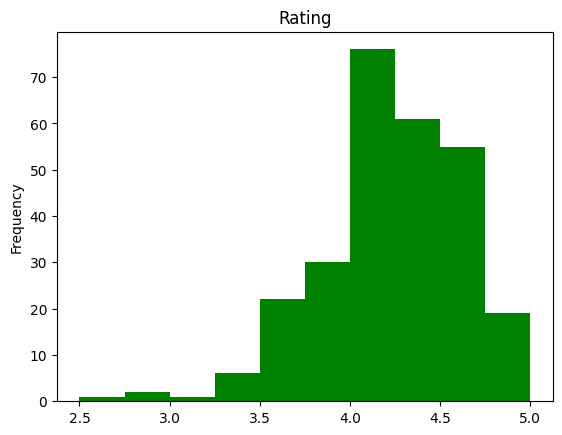

In [81]:
#Data_Visualtion
#kind = Histograms: shows the distribution of data.
df['Rating'].plot(kind='hist', color='green' , title='Rating')
plt.show()

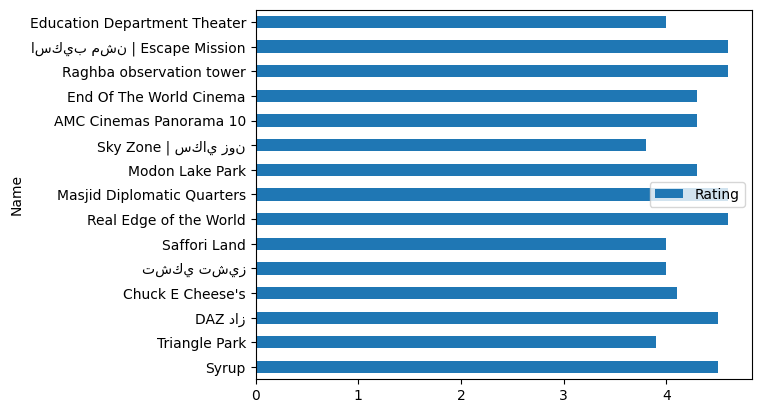

In [82]:
#kind = Bar Horzintal: displays and compares the rating values for the first 15 entries based on their names.

df_name_rating = df[['Name','Rating']].head(15)
df_name_rating.plot(x='Name', y='Rating',kind='barh')
plt.show()

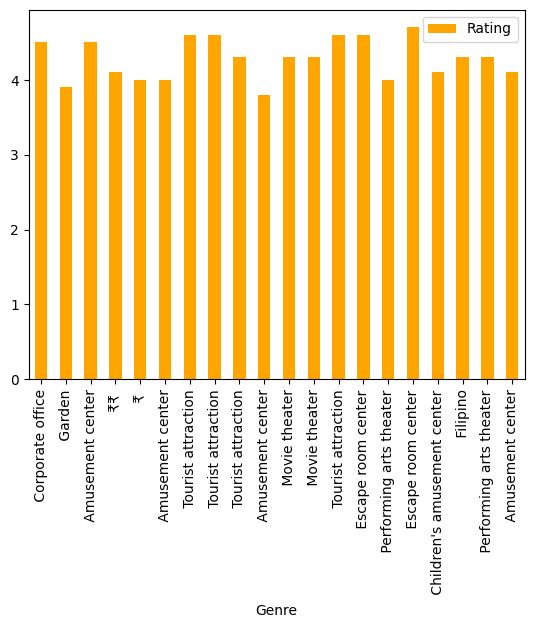

In [83]:
#kind = Bar Charts: shows comparisons between categories.

df_genre_rating = df[['Genre','Rating']].head(20)
df_genre_rating.plot(x='Genre', y='Rating',kind='bar', color='orange')
plt.show()

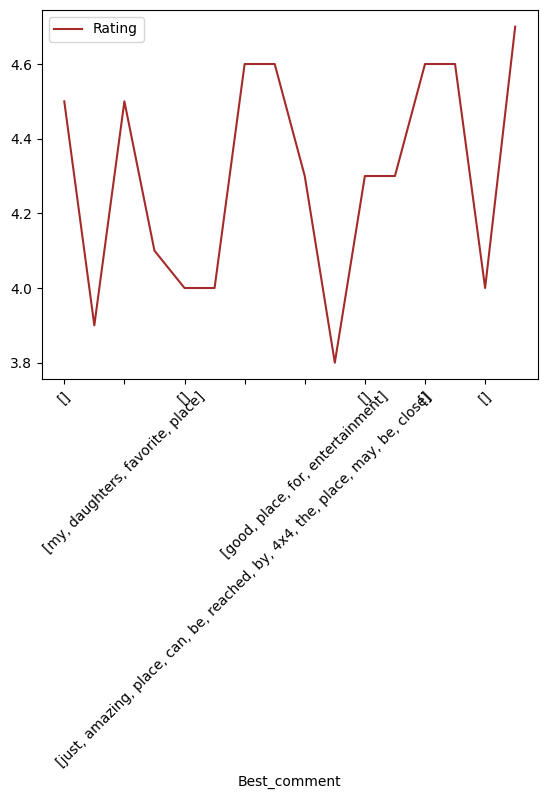

In [84]:
#kind = Line Graph: shows how values change over time.

df_best_rating = df[['Best_comment','Rating']].head(16)
df_best_rating.plot(x='Best_comment', y='Rating',kind='line', color='brown', rot=45 )
plt.show()

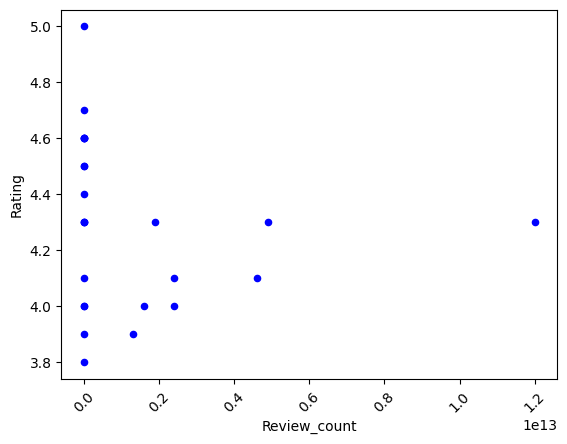

In [85]:
#kind = Scatter: shows how two variables are related

df_riview_rating = df[['Review_count','Rating']].head(25)
df_riview_rating.plot(x='Review_count', y='Rating',kind='scatter', color='blue', rot=45 )
plt.show()

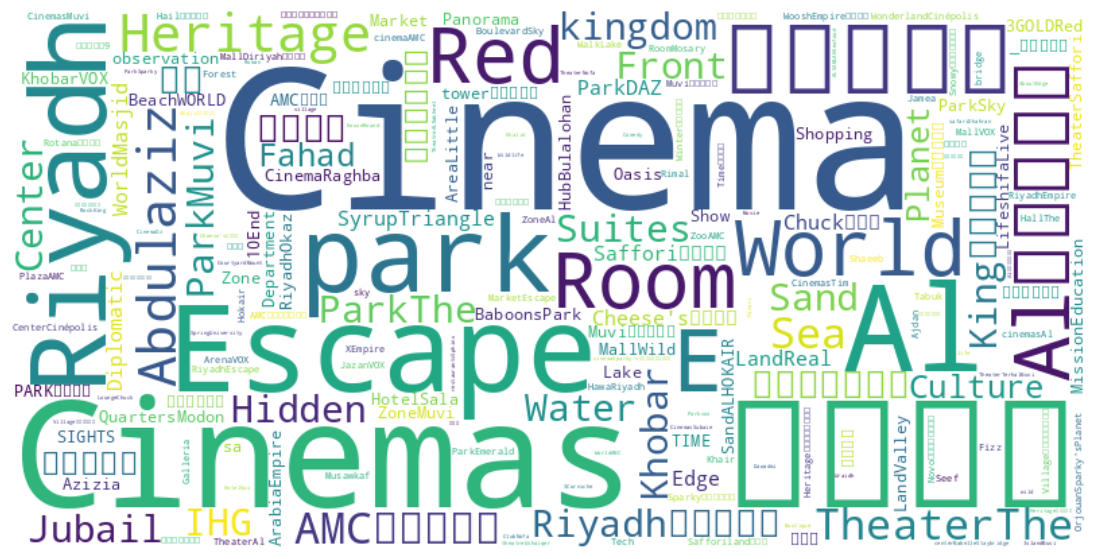

In [86]:
#kind = Word Cloud: shows the most repeated words.
from wordcloud import WordCloud
text = "".join (df ['Name'].dropna())
wr= WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(15,7))
plt.imshow(wr, interpolation='bilinear')
plt.axis('off')
plt.show()


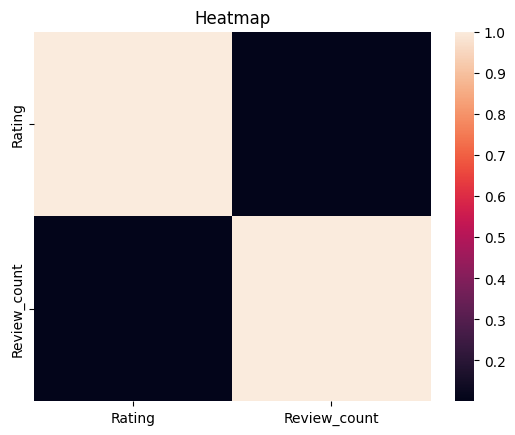

In [87]:
#kind = Heat Maps: shows the relation between numric columns.
df_rr = df[['Rating','Review_count']]
corr= df_rr.corr()
#هذا يرسمها
sns.heatmap(corr)
plt.title('Heatmap')
plt.show()


## Contribution Report

| Name | Contribution |
|------|--------------|
| Wateen | Data Processing: Filling or removing missing values (NaN values), removing duplicate records, and reformatting data. |
| Fatimah | Data Processing: Tokenizing text data and cleaning text (removing emojis, punctuation, and extra spaces). |
| Shahad Alwadani | Data Analysis: Calculating the correlation between variables and grouping and aggregating data. |
| Shahad Alrehaili | Data Analysis: Finding central values (mean, median, mode) and finding common words in text data (word frequency analysis). |
| Bayan | Data Visualization: Creating visualizations using matplotlib and seaborn. |